\begin{center}
{\large Victoria Arróniz Soriano}
\end{center}

# Overview

This project applies data analytics and machine learning techniques to analyse customer behaviour in the telecommunications sector, with a particular focus on customer churn and retention dynamics.

Using customer-level data from two contractual models (monthly and yearly contracts), the project aims to identify the key factors associated with customer churn, assess structural differences between contract types, and evaluate the predictive power of statistical and machine learning models. The analysis combines exploratory data analysis, hypothesis testing, supervised learning, and clustering techniques to provide a comprehensive, data-driven understanding of customer behaviour.

From a strategic perspective, the project addresses a relevant business and policy question: to what extent do contract structure, tenure, pricing, and service characteristics influence customer retention? By answering this question, the analysis provides insights that are directly applicable to customer retention strategies, market regulation, and evidence-based decision-making in service-oriented industries.

The project is implemented entirely in Python, using widely adopted libraries for data analysis, statistical modelling, and machine learning. Emphasis is placed not only on predictive performance, but also on interpretability, robustness, and consistency across analytical methods, ensuring that the results can support informed decisions rather than purely technical optimisation.

\vspace{0.5 cm}

# Data Description & Scope

The dataset telecom-monthly.csv was loaded into Python and stored as a pandas DataFrame. This dataset contains customer-level information for users subscribed to monthly contracts in the telecommunications sector and constitutes the first empirical basis of the analysis.

The DataFrame is hereafter referred to as monthly and is used throughout the project to analyse customer behaviour, churn patterns, and contractual characteristics associated with short-term agreements.
\vspace{0.2cm}

In [86]:
import pandas as pd
monthly = pd.read_csv("telecom-monthly.csv")

In [87]:
monthly.head()

,customer_id,tenure,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,streaming_services,payment_method,churn
0,1000,4,50.18,200.72,Month-to-month,Fiber optic,No,No,0,Mailed check,0
1,1001,12,56.73,680.76,Month-to-month,DSL,No,No,1,Electronic check,0
2,1002,5,73.26,366.30,Month-to-month,Fiber optic,No,No,1,Electronic check,0
3,1003,1,98.62,98.62,Month-to-month,Fiber optic,Yes,Yes,2,Electronic check,1
4,1004,9,75.42,678.78,Month-to-month,DSL,Yes,Yes,2,Electronic check,0


In [88]:
nrows = monthly.shape[0] # number of rows
ncols = monthly.shape[1] # number of columns
print('The number of rows is', nrows, 'and the number of columns is', ncols,'.' )

The number of rows is 800 and the number of columns is 11 .


An initial inspection of the dataset was conducted to understand its structure, scope, and data quality. The dataset contains 800 customer observations and 11 variables, each representing a specific aspect of customer behaviour, contractual conditions, service characteristics, or churn outcomes.

In [89]:
print(list(monthly.columns))

['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'streaming_services', 'payment_method', 'churn']


The variables included in the dataset are:

- customer_id (identifier)
- tenure
- monthly_charges
- total_charges
- contract_type
- internet_service
- tech_support
- online_security
- streaming_services
- payment_method
- churn

The variable customer_id functions exclusively as a unique identifier and does not carry analytical meaning. All remaining variables provide information relevant to behavioural, economic, or service-related dimensions of customer engagement.

In [90]:
monthly.isna().sum()

customer_id           0
tenure                0
monthly_charges       0
total_charges         0
contract_type         0
internet_service      0
tech_support          0
online_security       0
streaming_services    0
payment_method        0
churn                 0
dtype: int64

Data quality checks confirm that no missing values are present in any of the variables. This ensures that the dataset can be analysed directly without the need for imputation or sample adjustment, allowing for robust statistical analysis and modelling in subsequent sections.

Overall, the dataset provides a complete and well-structured representation of monthly-contract customers, suitable for exploratory analysis, hypothesis testing, and predictive modelling.

\vspace{0.3 cm}

# Exploratory Analysis & Market Insights

An exploratory data analysis was conducted to understand the main characteristics of the monthly-contract customer base, with particular attention to churn behaviour and the relationship between tenure and monthly charges.

In [91]:
print(monthly.dtypes)

customer_id             int64
tenure                  int64
monthly_charges       float64
total_charges         float64
contract_type          object
internet_service       object
tech_support           object
online_security        object
streaming_services      int64
payment_method         object
churn                   int64
dtype: object


The dataset contains a mix of numerical and categorical variables. Numerical variables include tenure, monthly_charges, total_charges, streaming_services, and churn, while categorical variables describe contract conditions, service characteristics, and payment methods.

## Categorical variables

In [92]:
cat_cols = monthly.select_dtypes("object")

In [93]:
Diff = []   # List of categories for each variable
Prop = []   # List of proportions for each variable

for col in cat_cols.columns:                         
    vc = cat_cols[col].value_counts(dropna=False)     # Count each category

    Diff.append(list(vc.index))                       # Store category names
    Prop.append(list((vc / vc.sum()).values))         # Store category proportions

summary_cat = pd.DataFrame({                        
    "Variable":   cat_cols.columns,                   # Variable names
    "Different":  Diff,                               # Categories
    "Proportion": Prop,                               # Proportions
})

summary_cat                                           

,Variable,Different,Proportion
0,contract_type,[Month-to-month],[1.0]
1,internet_service,"[Fiber optic, DSL, No]","[0.53875, 0.25875, 0.2025]"
2,tech_support,"[No, Yes]","[0.6475, 0.3525]"
3,online_security,"[No, Yes]","[0.63625, 0.36375]"
4,payment_method,"[Credit card, Electronic check, Bank transfer,...","[0.27, 0.26875, 0.26125, 0.2]"


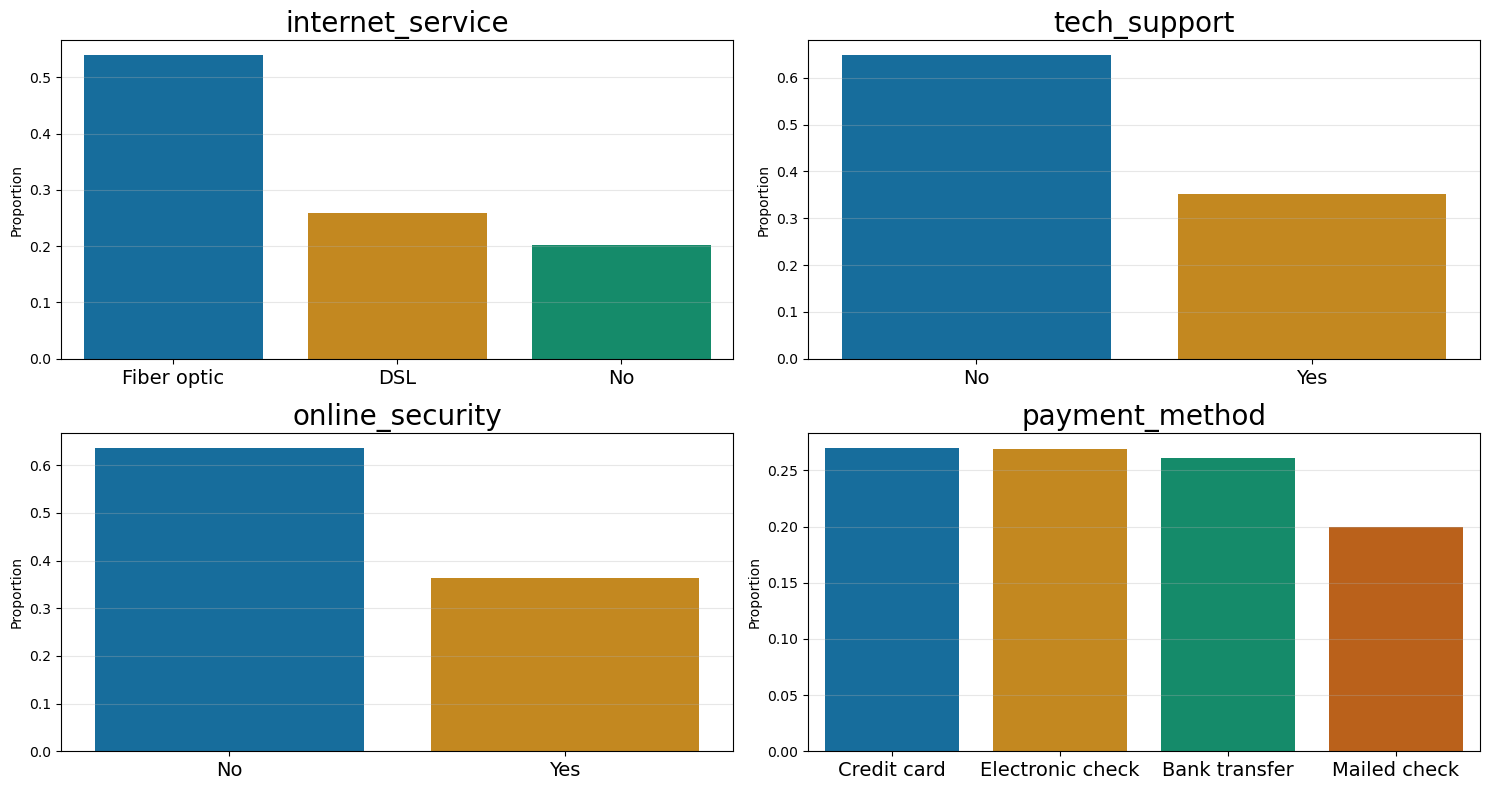

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the first row (contract_type) and reset the index
summary_no_contract = summary_cat.iloc[1:].reset_index(drop=True)

# Now extract everything from this reduced dataframe
variables = summary_no_contract["Variable"]
categories = summary_no_contract["Different"]
proportions = summary_no_contract["Proportion"]


# 2×2 grid of subplots (4 graphs in total)
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Flatten the 2×2 array of axes into a simple 1-D list for easier indexing
axes = axes.flatten()

for i in range(4):

    # List of categories for the i-th variable
    cats=categories[i]
    
    # List of proportions for the i-th variable
    props=proportions[i]

    # Select colors from rocket (n colours = number of categories)
    colours=sns.color_palette("colorblind", len(cats)) # Palette colour-blind friendly

    # Create a barplot 
    sns.barplot(
        x=cats,            # Categories, x-axis
        y=props,           # Proportions, y-axis
        hue=cats,          # Use categories as hue
        palette=colours,   # Colours
        ax=axes[i]         # Plot on the i-th subplot
    )

    # Size of x-labels
    axes[i].tick_params(axis='x', labelsize=14) 

    # Title of subplot
    axes[i].set_title(variables[i], fontsize=20)

    # Label the y-axis 
    axes[i].set_ylabel('Proportion')

    # Horizontal grid lines 
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The analysis of categorical variables highlights several structural features of the monthly-contract customer population. As expected, contract_type does not provide variation within this dataset, since all customers are subscribed to month-to-month contracts. While uninformative at this stage, this variable becomes relevant later when comparing monthly and yearly contract groups.

Regarding service characteristics, internet_service displays three categories (Fiber optic, DSL, and No internet service), with Fiber optic being the most common option, accounting for more than half of the customers. Both tech_support and online_security are binary variables, and in both cases the absence of the service is more frequent, with over 60% of customers not subscribing to these add-ons.

The payment_method variable shows a relatively balanced distribution across four categories (credit card, electronic check, bank transfer, and mailed check), with no single method dominating the customer base. This balanced structure suggests that payment method may play a role in churn behaviour rather than simply reflecting a default choice.

Overall, the categorical variables reveal a customer population with heterogeneous service configurations and payment behaviours, providing a useful basis for subsequent churn analysis.

## Numerical variables

In [95]:
monthly.describe()

,customer_id,tenure,monthly_charges,total_charges,streaming_services,churn
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,1399.5000,18.875000,65.000362,1256.837075,1.001250,0.43625
std,231.0844,17.411874,16.861907,1280.216807,0.782313,0.49623
min,1000.0000,1.000000,20.640000,22.940000,0.000000,0.00000
25%,1199.7500,6.000000,53.905000,346.280000,0.000000,0.00000
50%,1399.5000,13.000000,64.980000,827.985000,1.000000,0.00000
75%,1599.2500,26.000000,76.842500,1710.880000,2.000000,1.00000
max,1799.0000,72.000000,107.850000,7407.360000,2.000000,1.00000


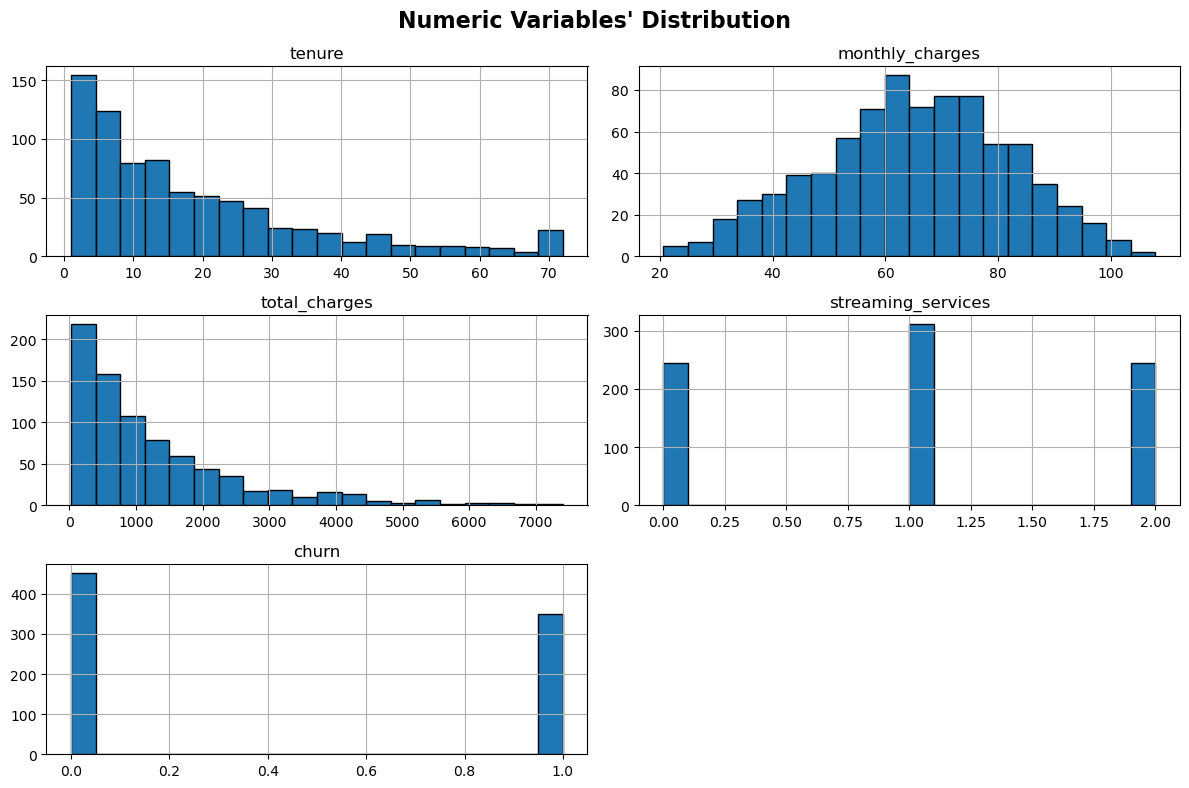

In [96]:
numeric_v = ["tenure", "monthly_charges", "total_charges", 
             "streaming_services", "churn"]

monthly[numeric_v].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Numeric Variables' Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


Descriptive statistics for the numerical variables reveal several important patterns. Customer tenure ranges from 1 to 72 months, with a mean of approximately 19 months. The distribution is strongly right-skewed, indicating that most customers have relatively short relationships with the provider, while a smaller group remains for several years.

Monthly charges are approximately bell-shaped and concentrated around a mean of about 65 monetary units, with values ranging from low-cost to premium plans. In contrast, total_charges exhibit strong right skewness, reflecting the cumulative nature of this variable and its close relationship with tenure.

The variable streaming_services is discrete, taking values of 0, 1, or 2, with the majority of customers subscribing to a single streaming service. The churn variable is binary and indicates whether a customer has discontinued the service.

From this point onward, the analysis focuses primarily on tenure, monthly_charges, and total_charges as the main numerical indicators of customer behaviour.

## Churn distribution

In [97]:
churn_col = monthly["churn"]         # Extract the churn column
n_churn = churn_col.value_counts()   # Count customers in each category 
percentages = n_churn / len(monthly) # Compute proportions for each category
percentages                         

churn
0    0.56375
1    0.43625
Name: count, dtype: float64

The distribution of churn shows that approximately 43.6% of customers have churned, while 56.4% have remained with the provider. Although non-churners represent a slight majority, the churn rate is substantial, highlighting customer retention as a key issue for monthly contracts.

This relatively high churn proportion reinforces the relevance of identifying behavioural and contractual factors associated with customer departure.

## Relationship between tenure, charges, and churn

The relationship between tenure and monthly_charges, visualised through a scatter plot coloured by churn status, provides additional insight into customer behaviour. Customers with short tenure are heavily concentrated at the lower end of the tenure distribution and display a higher incidence of churn. In contrast, customers with longer tenure are more dispersed and are predominantly non-churners.

The association between tenure and monthly charges appears weak, suggesting that pricing level alone does not strongly determine how long customers remain with the provider. Instead, the visual pattern indicates that tenure itself is a key driver of churn, with customer departures occurring disproportionately early in the customer lifecycle.

Overall, the exploratory analysis suggests that churn among monthly-contract customers is driven more by relationship duration and engagement than by pricing differences, an insight that motivates the statistical testing and predictive modelling developed in subsequent sections.

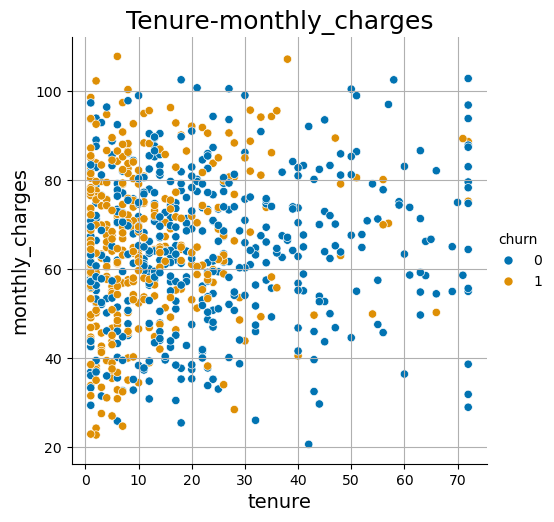

In [98]:
import seaborn as sns

plot_1 = sns.relplot(                   # Create a Seaborn relational plot
    data = monthly,                     # Data frame for plotting
    x = "tenure",                       # X variable
    y = "monthly_charges",              # Y variable
    hue = "churn",                      # Colour by churn
    kind = "scatter",                   # Scatter plot
    height = 5,                         # Figure height
    aspect = 1,                         # Aspect ratio
    palette = "colorblind"              # Palette color-blind friendly
)
plt.xlabel("tenure",fontsize = 14)                 # X label 
plt.ylabel("monthly_charges", fontsize = 14)        # Y label
plt.title("Tenure-monthly_charges", fontsize = 18) # Title
plt.grid(True)                                     # Show gid
plt.show()

\vspace{0.3 cm}

# Statistical Testing of Contract Models

## Yearly contract dataset: structure and comparability

\vspace{0.3cm}

The dataset telecom-yearly.csv contains customer-level information for users subscribed to yearly (annual) contracts. This dataset includes 600 customer observations and 11 variables, mirroring exactly the structure of the monthly-contract dataset.

In [99]:
yearly  = pd.read_csv("telecom-yearly.csv")

In [100]:
yearly.head()

,customer_id,tenure,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,streaming_services,payment_method,churn
0,2000,66,70.35,4643.10,Annual,Fiber optic,No,No,2,Bank transfer,0
1,2001,14,57.46,804.44,Annual,DSL,No,No,1,Credit card,1
2,2002,38,75.46,2867.48,Annual,Fiber optic,No,No,2,Bank transfer,0
3,2003,1,60.79,60.79,Annual,Fiber optic,No,No,0,Mailed check,0
4,2004,3,74.40,223.20,Annual,DSL,Yes,Yes,1,Bank transfer,1


In [101]:
nrows_y = yearly.shape[0] # number of rows
ncols_y = yearly.shape[1] # number of columns
print("Number of rows:", nrows_y,"\n")
print("Number of columns:", ncols_y)

Number of rows: 600 

Number of columns: 11


All variables present in the monthly dataset are also available for yearly customers, including tenure, billing information, service characteristics, payment method, and churn status. A direct comparison of variable names confirms that both datasets share the same variables in the same order, ensuring full comparability across contract types.

In [102]:
print(list(yearly.columns))

['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'streaming_services', 'payment_method', 'churn']


In [103]:
list(monthly.columns) == list(yearly.columns)

True

As in the monthly dataset, contract_type is constant within the yearly dataset (Annual) and therefore does not provide within-group variation. However, this feature enables a clear separation between contractual models and supports a clean comparative analysis of customer behaviour across monthly and yearly contracts

\vspace{0.3 cm}

## Comparison of numerical indicators across contract types

To assess whether customer characteristics differ systematically between monthly and yearly contracts, two-sample independent t-tests were conducted for the main numerical variables: tenure, monthly_charges, and total_charges. The null hypothesis in each case states that the mean value of the indicator is equal across contract types. All tests were evaluated using a significance level of $\alpha = 0.05$.

$$H_0: \mu_1-\mu_2=0 \qquad H_1: \mu_1-\mu_2 \neq 0.$$ 

In [104]:
import scipy.stats as stats                   

tenure_m  = monthly["tenure"]                # Tenure for monthly customers
tenure_y  = yearly["tenure"]                 # Tenure for yearly customers

mon_charges_m  = monthly["monthly_charges"]  # Monthly charges (monthly)
mon_charges_y  = yearly["monthly_charges"]   # Monthly charges (yearly)

total_charges_m  = monthly["total_charges"]  # Total charges (monthly)
total_charges_y  = yearly["total_charges"]   # Total charges (yearly)

t1, p1 = stats.ttest_ind(tenure_m, tenure_y)             # t-test, tenure
t2, p2 = stats.ttest_ind(mon_charges_m, mon_charges_y)   # t-test, monthly charges
t3, p3 = stats.ttest_ind(total_charges_m, total_charges_y) # t-test, total charges

results = pd.DataFrame({                                 # Data frame
    "Variable": ["tenure", "monthly_charges", "total_charges"],
    "t_score":  [t1, t2, t3],
    "p_value":  [p1, p2, p3],
    "p_value<0.05": [p1<0.05, p2<0.05, p3<0.05]
})

results

,Variable,t_score,p_value,p_value<0.05
0,tenure,-11.272065,2.867196e-28,True
1,monthly_charges,-1.313822,1.891218e-01,False
2,total_charges,-10.314891,4.300298e-24,True


To evaluate whether the numerical indicators differ between customers on monthly and yearly contracts, the p-values obtained obtained from the t-tests are compared with the significance level $\alpha = 0.05$.
- If $p< 0.05$ , we reject the null hypothesis ($H_0$) , concluding that the corresponding measurement differs significantly between the two contract types.

- If $p \geq 0.05$, we fail to reject $H_0$, indicating that there is no statistical evidence of a difference between the groups.

Applying this decision rule yields the following results:

- Tenure. The p-value associated with the tenure comparison is smaller than 0.05, leading us to reject the null hypothesis.
This indicates that tenure differs significantly between monthly and yearly customers.

- Monthly charges. The p-value for monthly charges is greater than 0.05, so we fail to reject the null hypothesis.
Thus, there is no evidence that the average monthly charge differs between the two contract types. 

- Total charges. The p-value for total charges is below 0.05, which leads us to reject the null hypothesis. Therefore, total charges differ significantly between monthly and yearly customers. 

Overall, these results indicate that contract type is strongly associated with relationship duration and cumulative customer value, while average monthly pricing remains largely independent of the contractual model.

\vspace{0.3 cm}

## Churn differences across contract types

To examine whether churn behaviour differs between monthly and yearly contracts, a chi-square test of independence was performed using a contingency table of churn outcomes by contract type. The null hypothesis assumes that churn is independent of contract type.

In [105]:
# Churn counts for each contract type
churn_m = monthly["churn"].value_counts()     # Monthly customers
churn_y = yearly["churn"].value_counts()      # Yearly customers

# Observed contingency table
table = pd.DataFrame({                    
    "No_churn": [churn_m[0], churn_y[0]],        # Col 0: churn = 0
    "Churn":    [churn_m[1], churn_y[1]]         # Col 1: churn = 1
}, index = ["Monthly", "Yearly"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(table)

In [106]:
table        # Observed counts

,No_churn,Churn
Monthly,451,349
Yearly,461,139


In [107]:
expected_df = pd.DataFrame(expected, 
                   index=["Monthly", "Yearly"], 
                   columns=["No_churn",	"Churn"])
expected_df

,No_churn,Churn
Monthly,521.142857,278.857143
Yearly,390.857143,209.142857


In [108]:
chi2_stats = pd.DataFrame(
    {
        "Chi-square statistic": [chi2_stat],
        "p-value":              [p_value],
        "Degrees of freedom":   [dof],
    },
    index=["Chi-square test"]
)
chi2_stats

,Chi-square statistic,p-value,Degrees of freedom
Chi-square test,62.299042,2.950686e-15,1


The chi-square test strongly rejects the null hypothesis at the $5\%$ significance level. Specifically, the result is driven by an extremely small p-value:
$$
\text{p-value} =2.950686e-15 < 0.05=\alpha
$$
As a consequence, the null hypothesis ($H_0$) is rejected, and we conclude that contract type and churn behaviour are not independent. This provides robust statistical evidence that churn rates differ significantly between monthly and yearly customers.

A graphical comparison of churn rates further reinforces this conclusion. Monthly-contract customers display a substantially higher churn rate than yearly-contract customers. The visual difference aligns closely with the statistical test results and highlights the stabilising effect of longer-term contractual arrangements.

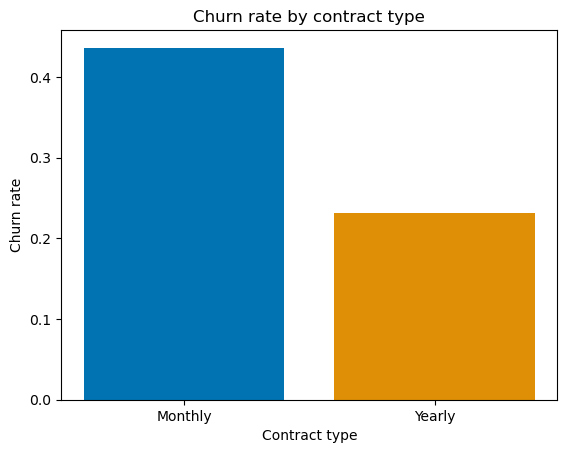

In [109]:
# Churn proportions in each contract type
prop_m = churn_m[1] / churn_m.sum()              # Churn rate (monthly)
prop_y = churn_y[1] / churn_y.sum()              # Churn rate (yearly)

plt.figure()
plt.bar(["Monthly", "Yearly"], [prop_m, prop_y], color=colours)  # Bar plot of churn rates
plt.xlabel("Contract type")
plt.ylabel("Churn rate")
plt.title("Churn rate by contract type")
palette = "colorblind"                            # Palette color-blind friendly
plt.show()

Taken together, the statistical evidence demonstrates that yearly contracts are associated with significantly lower churn and longer customer relationships, while monthly contracts exhibit higher churn despite similar pricing levels. These findings motivate the predictive modelling and segmentation analyses developed in subsequent sections.

\vspace{0.5 cm}

# Integrated Dataset and Correlation Analysis

\vspace{0.3 cm}

## Integration of monthly and yearly datasets

Prior analysis showed that the variable contract_type is constant within each dataset: all observations in the monthly dataset correspond to month-to-month contracts, while all observations in the yearly dataset correspond to annual contracts. As a result, contract_type does not provide meaningful within-dataset variation.

In [110]:
yearly["contract_type"].value_counts()   # Check contract types in yearly dataset

contract_type
Annual    600
Name: count, dtype: int64

In [111]:
monthly["contract_type"].value_counts()  # Check contract types in monyhly dataset

contract_type
Month-to-month    800
Name: count, dtype: int64

To enable joint analysis while preserving information on contractual structure, the two datasets were combined into a single dataset. A new categorical variable, dataset, was introduced to identify the original source of each observation (Monthly or Yearly). The variable contract_type was subsequently removed, as contractual differentiation is fully captured by the new dataset indicator.

In [112]:
monthly["dataset"] = "Monthly"        # Dataset name for all monthly rows
yearly["dataset"]  = "Yearly"         # Dataset name for all yearly rows

telecom = pd.concat([monthly, yearly])          # Stack monthly and yearly data
telecom = telecom.drop("contract_type", axis=1) # Drop contract_type column

telecom.head()                                

,customer_id,tenure,monthly_charges,total_charges,internet_service,tech_support,online_security,streaming_services,payment_method,churn,dataset
0,1000,4,50.18,200.72,Fiber optic,No,No,0,Mailed check,0,Monthly
1,1001,12,56.73,680.76,DSL,No,No,1,Electronic check,0,Monthly
2,1002,5,73.26,366.30,Fiber optic,No,No,1,Electronic check,0,Monthly
3,1003,1,98.62,98.62,Fiber optic,Yes,Yes,2,Electronic check,1,Monthly
4,1004,9,75.42,678.78,DSL,Yes,Yes,2,Electronic check,0,Monthly


In [113]:
nrows = telecom.shape[0] # number of rows
ncols = telecom.shape[1] # number of columns
print('The number of rows is', nrows, 'and the number of columns is', ncols,'.' )

The number of rows is 1400 and the number of columns is 11 .


The resulting combined dataset contains 1,400 observations and includes customer tenure, billing variables, service characteristics, payment method, churn status, and a clear identifier of contract type at the dataset level. This integrated structure provides the basis for correlation analysis and subsequent predictive modelling.

\vspace{0.3 cm}
## Correlation analysis of numerical indicators

To quantify the linear relationships between key numerical indicators, Pearson correlation coefficients were computed for all pairs of continuous variables in the combined dataset. The analysis focuses on tenure, monthly_charges, and total_charges, as these variables represent core dimensions of customer engagement and economic value.

In [114]:
from scipy import stats
# Numerical variables as indicated in discussion
num_cols = telecom[["tenure","monthly_charges", "total_charges"]]  
# Names of numerical variables
num_var_names = list(num_cols.columns)                 

Pearson = [] # List to store results

for i in range(len(num_var_names)): 
    # Only pairs with j > i (avoid duplicates)
    for j in range(i + 1, len(num_var_names)):         
        x = num_cols[num_var_names[i]]     # First variable
        y = num_cols[num_var_names[j]]     # Second variable
        r, p = stats.pearsonr(x, y)        # Pearson correlation and p-value
        Pearson.append([num_var_names[i], num_var_names[j], r, p])

# Dataframe with all pairs
Pearson_df = pd.DataFrame(Pearson, columns=[
    "Variable_1", "Variable_2", "r", "p_value"
])

# Dataframe shorted
Pearson_df_short = Pearson_df.reindex(
    Pearson_df["r"].abs().sort_values(ascending=False).index
    ).head(3)     # Select the three higher values

Pearson_df_short

,Variable_1,Variable_2,r,p_value
1,tenure,total_charges,0.937605,0.000000e+00
2,monthly_charges,total_charges,0.312727,3.877027e-33
0,tenure,monthly_charges,0.060463,2.367526e-02


The correlation analysis identifies the following relationships:
- Tenure and Total charges, exhibit a strong positive correlation ($r\approx 0.94$), indicating that customers with longer relationships naturally accumulate higher total charges over time.
- Monthly charges and Total charges, show a moderate positive correlation ($r\approx 0.31$), suggesting that higher monthly prices contribute to higher cumulative spending, although with substantial variability.
- Tenure and Total charges,display a very weak positive correlation ($r\approx 0.06$), indicating that pricing levels are largely independent of how long customers remain with the provider.

This analysis confirms that total charges are primarily driven by tenure, rather than by systematic differences in monthly pricing.

Other variables, such as customer_id, streaming_services, and churn, were excluded from the correlation analysis. The identifier variable carries no analytical meaning, streaming_services is a discrete count variable, and churn is binary; consequently, Pearson’s correlation is not an appropriate measure for these variables.

\vspace{0.3 cm}

## Visual assessment of correlated relationships

To complement the numerical correlation analysis, scatter plots with fitted regression lines were used to visualise the strongest linear relationships identified in the previous section.

In [115]:
import statsmodels.formula.api as smf

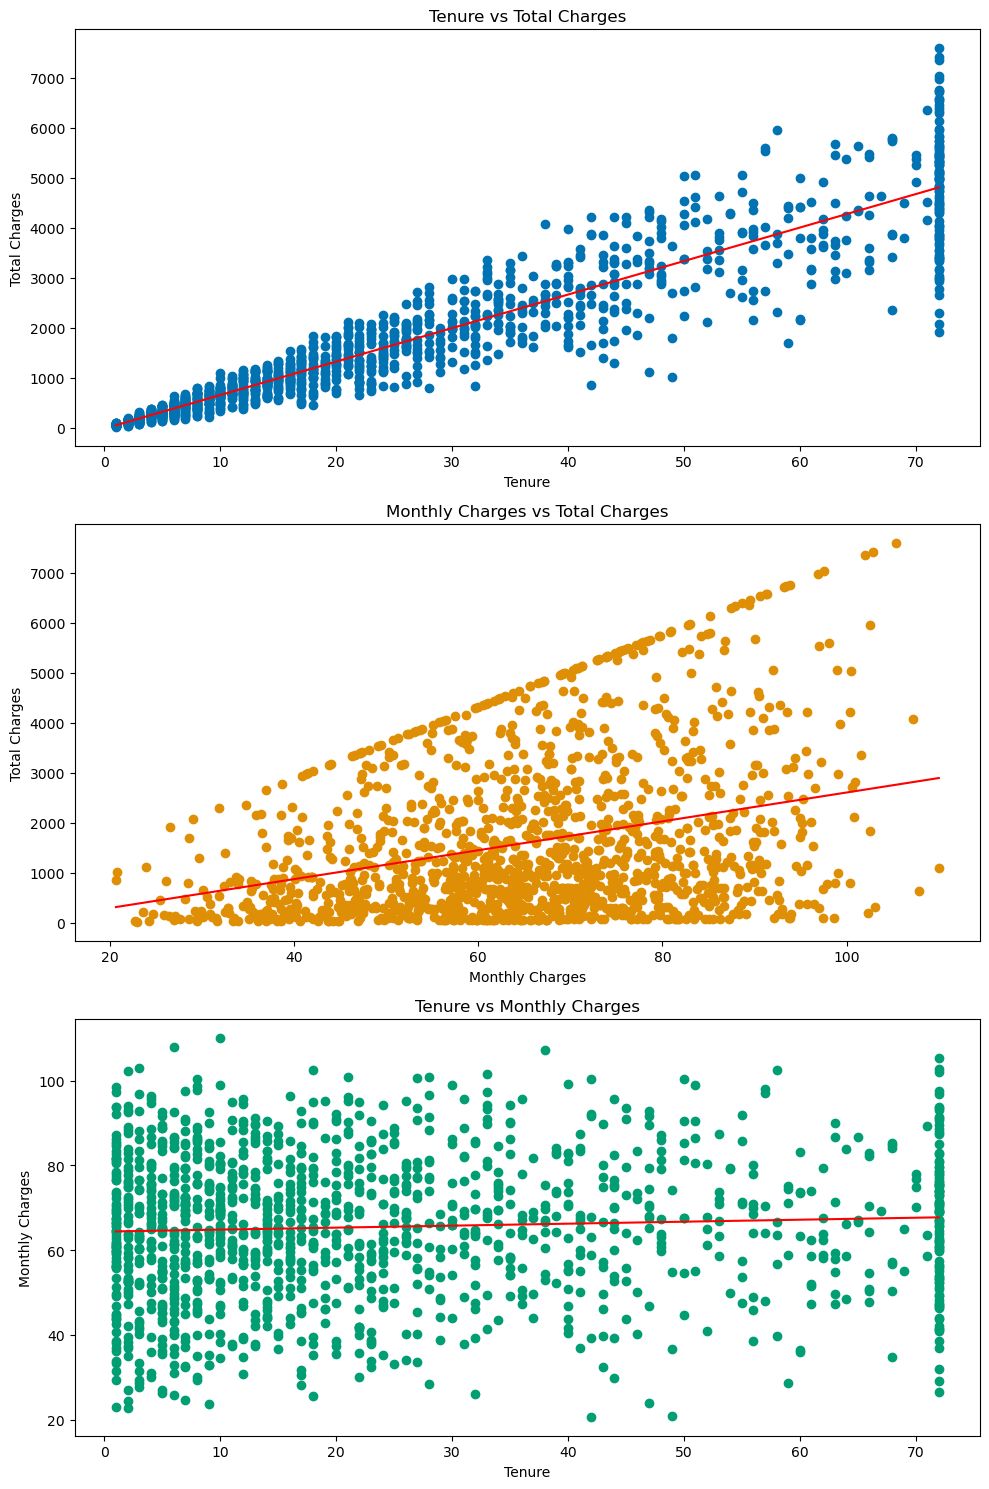

In [116]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))  # 1 row, 3 columns

# Palette color-blind friendly
colours = sns.color_palette("colorblind", 3)  # 3 plots → 3 colours

# Flatten the 3×1 array of axes into a simple 1-D list for easier indexing
axes = axes.flatten()

# Tenure vs Total Charges
model1 = smf.ols("total_charges ~ tenure", 
                 data=telecom).fit()                       # Linear model
df1 = telecom[["tenure", "total_charges"]].copy()          # Subset data
df1["pred"] = model1.predict(df1)                          # Fitted values
df1 = df1.sort_values("tenure")                            # Sort 

axes[0].scatter(df1["tenure"], df1["total_charges"], color = colours[0])   
axes[0].plot(df1["tenure"], df1["pred"], color="red") # Regression line           
axes[0].set_xlabel("Tenure")
axes[0].set_ylabel("Total Charges")
axes[0].set_title("Tenure vs Total Charges")

# Monthly Charges vs Total Charges
model2 = smf.ols("total_charges ~ monthly_charges", 
                 data = telecom).fit()                      # Linear model
df2 = telecom[["monthly_charges", "total_charges"]].copy()  # Subset data
df2["pred"] = model2.predict(df2)                           # Fitted values
df2 = df2.sort_values("monthly_charges")                    # Sort 

axes[1].scatter(df2["monthly_charges"], df2["total_charges"], color=colours[1])   
axes[1].plot(df2["monthly_charges"], df2["pred"], color="red")  # Regression line
axes[1].set_xlabel("Monthly Charges")
axes[1].set_ylabel("Total Charges")
axes[1].set_title("Monthly Charges vs Total Charges")

# Tenure vs Monthly Charges
model3 = smf.ols("monthly_charges ~ tenure",
                 data=telecom).fit()                         # Linear model
df3 = telecom[["tenure", "monthly_charges"]].copy()          # Subset data
df3["pred"] = model3.predict(df3)                            # Fitted values
df3 = df3.sort_values("tenure")                              # Sort 

axes[2].scatter(df3["tenure"], df3["monthly_charges"], color=colours[2]) 
axes[2].plot(df3["tenure"], df3["pred"], color="red") # Regression line                  
axes[2].set_xlabel("Tenure")
axes[2].set_ylabel("Monthly Charges")
axes[2].set_title("Tenure vs Monthly Charges")



plt.tight_layout()
plt.show()

The relationship between tenure and total charges forms a tight, upward-sloping pattern. The fitted regression line rises sharply and closely follows the data, reflecting the very strong positive correlation. This pattern confirms that accumulated spending is fundamentally linked to relationship duration.

The plot of monthly charges versus total charges shows a looser, fan-shaped distribution. While the regression line slopes upward, substantial dispersion around the line is evident, consistent with the moderate correlation coefficient. This suggests that monthly pricing contributes to total charges, but is not the dominant factor.

In contrast, the tenure versus monthly charges plot shows no clear linear structure. The regression line is nearly flat, indicating that customers do not systematically move to higher or lower monthly charges as their tenure increases. This visual evidence aligns with the very weak correlation observed between these variables.

Overall, the visual analysis is fully consistent with the correlation results and reinforces the conclusion that tenure is the central structural driver of cumulative customer value, while monthly pricing plays a secondary role.

\vspace{0.5 cm}

# Predictive Modelling: Logistic Regression

\Large\textbf{Logistic regression to predict customer churn}\normalsize

\vspace{0.3 cm}

## Data preparation and model specification

To capture potential non-linear effects of customer tenure on churn behaviour, a new categorical variable, tenure_category, was created by grouping tenure into three meaningful intervals:

- SHORT: 0–12 months

- MEDIUM: 13–36 months

- LONG: 37 months and above

This categorisation reflects typical stages in the customer lifecycle and allows the model to distinguish between early-stage customers, medium-term relationships, and long-standing customers. The variable is used alongside continuous tenure measures to assess whether churn risk changes discretely across these tenure segments.

In [117]:
max_tenure = telecom["tenure"].max()            # Maximum observed tenure

telecom["tenure_category"] = pd.cut(
    telecom["tenure"],                          # Variable to bin
    bins = [0, 12, 36, max_tenure],             # (0,12], (12,36], (36,max]
    labels = ["SHORT", "MEDIUM", "LONG"]        # Category labels
)

telecom.head()  

,customer_id,tenure,monthly_charges,total_charges,internet_service,tech_support,online_security,streaming_services,payment_method,churn,dataset,tenure_category
0,1000,4,50.18,200.72,Fiber optic,No,No,0,Mailed check,0,Monthly,SHORT
1,1001,12,56.73,680.76,DSL,No,No,1,Electronic check,0,Monthly,SHORT
2,1002,5,73.26,366.30,Fiber optic,No,No,1,Electronic check,0,Monthly,SHORT
3,1003,1,98.62,98.62,Fiber optic,Yes,Yes,2,Electronic check,1,Monthly,SHORT
4,1004,9,75.42,678.78,DSL,Yes,Yes,2,Electronic check,0,Monthly,SHORT


Prior to model estimation, categorical variables were encoded to ensure compatibility with logistic regression modelling. Binary indicator variables were created for categorical features such as service characteristics, payment method, contractual dataset, and tenure category, using appropriate reference categories.

In [118]:
# Select categorical variables
cat_vars = telecom.select_dtypes(include="object") 
# Encode variables
telecom_encoded = pd.get_dummies(telecom, drop_first=True)
telecom_encoded.head()

,customer_id,tenure,monthly_charges,total_charges,streaming_services,churn,internet_service_Fiber optic,internet_service_No,tech_support_Yes,online_security_Yes,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check,dataset_Yearly,tenure_category_MEDIUM,tenure_category_LONG
0,1000,4,50.18,200.72,0,0,True,False,False,False,False,False,True,False,False,False
1,1001,12,56.73,680.76,1,0,False,False,False,False,False,True,False,False,False,False
2,1002,5,73.26,366.30,1,0,True,False,False,False,False,True,False,False,False,False
3,1003,1,98.62,98.62,2,1,True,False,True,True,False,True,False,False,False,False
4,1004,9,75.42,678.78,2,0,False,False,True,True,False,True,False,False,False,False


In [119]:
telecom_encoded.columns = telecom_encoded.columns.str.replace(" ", "_")

Numerical predictors (tenure, monthly_charges, and total_charges) were standardised to ensure comparability of coefficient magnitudes and to improve numerical stability during model estimation.

In [120]:
telecom_std = telecom_encoded.copy()
# Numerical variables as indicated in discussion
num_cols = ["tenure","monthly_charges", "total_charges"]  

for col in num_cols:
    telecom_std[col] = (telecom_std[col] - 
                            telecom_std[col].mean())/ telecom_std[col].std()

telecom_std.head()

,customer_id,tenure,monthly_charges,total_charges,streaming_services,churn,internet_service_Fiber_optic,internet_service_No,tech_support_Yes,online_security_Yes,payment_method_Credit_card,payment_method_Electronic_check,payment_method_Mailed_check,dataset_Yearly,tenure_category_MEDIUM,tenure_category_LONG
0,1000,-0.939584,-0.918244,-0.916282,0,0,True,False,False,False,False,False,True,False,False,False
1,1001,-0.568652,-0.525853,-0.604448,1,0,False,False,False,False,False,True,False,False,False,False
2,1002,-0.893218,0.464409,-0.808721,1,0,True,False,False,False,False,True,False,False,False,False
3,1003,-1.078684,1.983649,-0.982606,2,1,True,False,True,True,False,True,False,False,False,False
4,1004,-0.707752,0.593808,-0.605734,2,0,False,False,True,True,False,True,False,False,False,False


The response variable is churn, defined as a binary outcome indicating whether a customer discontinued the service. All remaining variables, excluding the customer identifier, were included as candidate predictors in the initial model specification.

In [121]:
y = telecom_std["churn"]                               # Response variable
X = telecom_std.drop(["churn", "customer_id"], axis=1) # Predictor variables

\vspace{0.3 cm}

## Logistic regression results and interpretation

A multivariate logistic regression model was estimated to predict the probability of customer churn.

In [122]:
logit_smf = smf.logit(
    formula = 'churn ~ ' + ' + '.join(X.columns),   # All predictors in X
    data = telecom_std    # Encoded and standardised data
).fit()

print(logit_smf.summary())

Optimization terminated successfully.
         Current function value: 0.507476
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1385
Method:                           MLE   Df Model:                           14
Date:                Sun, 28 Dec 2025   Pseudo R-squ.:                  0.2151
Time:                        19:31:45   Log-Likelihood:                -710.47
converged:                       True   LL-Null:                       -905.18
Covariance Type:            nonrobust   LLR p-value:                 2.134e-74
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   0.3493

The model converged successfully, and the likelihood ratio test indicates that the fitted model is highly significant overall (LLR $p$-value $\approx 2.134\times 10^{-74}$). The goodness of fit can be summarised using pseudo–$R^{2}$, which for this model is

$$
R^{2} = 0.2151,
$$

indicating a substantial improvement over the null model, though the overall fit remains moderate

Coefficients are interpreted in terms of their effect on the log-odds of churn, holding all other variables constant. A positive coefficient increases the probability of churn, whereas a negative coefficient decreases it. Statistical significance is assessed using the associated $p$-values. Following the convention used earlier, we adopt a significance level of $\alpha = 0.05$ and consider a predictor to be significant whenever its $p$-value is below this threshold.

For continuous predictors, the coefficient represents the expected change in the log-odds of churn associated with a one-unit increase in the predictor, holding all other variables constant. For categorical predictors, the coefficient represents the difference in log-odds relative to the baseline category.

- Significant positive predictors:
    1.  payment_method_Electronic_check  (coef. $= 0.80$, $p < 0.001$). Customers paying by electronic check exhibit a significantly higher probability of churn. This is the strongest positive predictor in the model, suggesting that payment friction or customer profile differences may be linked to disengagement.
    2.  total_charges  (standardise; coef. $= 1.28$, $p = 0.004$). Higher accumulated charges are associated with a modest increase in churn probability, potentially reflecting customer fatigue or price sensitivity among long-term high-spending customers.

- Significant negative predictors:
    1.  tenure_category_LONG  (coef. $= -2.46$, $p < 0.001$). Customers with long tenure (37+ months) have a substantially lower probability of churn than short-tenure customers. This is the strongest effect in the model.
    2.  dataset_Yearly (coef. $= -0.6368$, $p< 0.001$). Customers on yearly contracts are significantly less likely to churn compared to those on monthly contracts, consistent with the chi-square results.
    4.  tenure_category_MEDIUM  (coef. $= -0.89$, $p < 0.001$). Medium-tenure customers (13–36 months) also show a significantly lower probability of churn relative to short-tenure customers.
    5.  tech_support_Yes  (coef. $= -0.53$, $p = 0.010$). Having technical support reduces churn probability; supported customers are less likely to leave.
    6.  internet_service_No  (coef. $= -0.73$, $p = 0.011$). Customers without internet service are less likely to churn, likely reflecting lower service engagement.
    7.  tenure  (standardised; coef. $=  -1.52$, $p = 0.003$). Greater standardised tenure reduces churn probability even after accounting for tenure categories, confirming a strong negative association between tenure and churn.

The remaining predictors have $p$-values greater than $0.05$ and are therefore not statistically significant:  monthly_charges ,  streaming_services ,  payment_method_Credit_card ,  payment_method_Mailed_check ,  internet_service_Fiber_optic  and  online_security_Yes .


\vspace{0.3 cm}
## Model refinement and performance comparison

To assess model parsimony, a backward elimination procedure was applied, iteratively removing predictor with the largest p-value above the threshold $\alpha=0.05$, refit the model, and repeat until all remaining variables are significant.

In [123]:
X_i = X.copy()
back_eli = logit_smf 

while True:
    # The intercept is not a variable
    pvals = back_eli.pvalues.drop('Intercept')  
    
    worst_p = pvals.max()                           # Worst p-value
    worst = pvals.idxmax().replace("[T.True]", "")  # Column worst p-value

    # Stop if all p-values are below threshold
    if worst_p < 0.05:
        break

    # Remove the worst predictor
    X_i=X_i.drop(worst, axis=1)
    
    # Fit the new model 
    formula = 'churn ~ ' + ' + '.join(X_i.columns)
    back_eli = smf.logit(formula=formula, 
                        data=telecom_std
                       ).fit(disp=False)
back_eli.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1391
Method:                           MLE   Df Model:                            8
Date:                Sun, 28 Dec 2025   Pseudo R-squ.:                  0.2124
Time:                        19:31:45   Log-Likelihood:                -712.92
converged:                       True   LL-Null:                       -905.18
Covariance Type:            nonrobust   LLR p-value:                 3.842e-78
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   0.3662      0.242      1.515      0.130      -0.108       0.840
internet_service_No[T.True]                -0.5521      0.188     -2.929      0.003      -0.922      -0.183
tech_support_Yes[T.True]                   -0.7151      0.149     -4.808      0.000      -1.007      -0.424
payment_method_Electronic_check[T.True]     0.7567      0.144      5.254      0.000       0.474       1.039
dataset_Yearly[T.True]                     -0.6327      0.137     -4.620      0.000      -0.901      -0.364
tenure_category_MEDIUM[T.True]             -0.8980      0.224     -4.016      0.000      -1.336      -0.460
tenure_category_LONG[T.True]               -2.4129      0.593     -4.072      0.000      -3.574      -1.252
tenure                                     -1.1017      0.420     -2.621      0.009      -1.926      -0.278
total_charges                               0.8422      0.348      2.420      0.016       0.160       1.524
===========================================================================================================
"""

The model obtained applaying backward elimination was: 

In [124]:
formula

'churn ~ tenure + total_charges + internet_service_No + tech_support_Yes + payment_method_Electronic_check + dataset_Yearly + tenure_category_MEDIUM + tenure_category_LONG'

The selected model has 8 variables ,which is a substantial reduction in the number of variables compared with the full model, which has 15. The reduced model also has a R square of $0.2124$ a very small reduction in pseudo-$R^2$ for a much simpler model (the pseudo-$R^2$ of the full model is $0.2125$). 

The resulting reduced model retains 8 predictors (all of them significant), compared to 15 in the full specification, while maintaining a pseudo-$R^2$ of$0.2124$, only marginally lower than that of the full model (pseudo-$R^2=0.2125$). This indicates that most explanatory power is concentrated in a small subset of variables.

The classification accuracy of the two models was also compared.

In [125]:
y_true = telecom_std["churn"]                # True churn labels

# Full model accuracy
p_full = logit_smf.predict(telecom_std)          # Predicted 
yhat_full = (p_full >= 0.5).astype(int)          # Class predictions alpha= 0.5 
accuracy_full = (yhat_full == y_true).mean()     # Proportion of correct predictions

# Backward elimination model accuracy 
p_reduced = back_eli.predict(telecom_std)      # Predicted  
yhat_reduced = (p_reduced >= 0.5).astype(int)       # Class predictions alpha= 0.5
accuracy_reduced = (yhat_reduced == y_true).mean()  # Proportion correct predictions

# DataFrame
Accuracy = pd.DataFrame(          
    [[accuracy_full, accuracy_reduced]],       
    columns=["Full model", "Backward model"]          
)

Accuracy           

,Full model,Backward model
0,0.725,0.720714


Predictive performance was evaluated using classification accuracy with a threshold of $0.05$. The full model achieves an accuracy of approximately $72.5\%$, while the reduced model achieves an accuracy of approximately $72.1\%$. The difference in performance is negligible.

Taken together, these results suggest that the reduced model offers an effective trade-off between interpretability and predictive performance, capturing the core drivers of churn with substantially lower complexity.

\vspace{0.5 cm}

# Machine Learning Validation: Random Forest

\Large \textbf{Random forest classification to predict customer churn}\normalsize

\vspace{0.3 cm}

## Random forest model and variable importance

To evaluate model performance in a realistic predictive setting, the encoded and standardised dataset was split into a training set ($70\%$ of the observations) and a test set ($30\%$). The split was performed randomly, using a fixed seed to ensure reproducibility. We used NumPy’s random permutation to generate a random ordering of the indices and then selected the first $70\%$ for training and the remaining $30\%$ for testing.

In [126]:
import numpy as np
train_size = int(0.7*len(y))  # Number of observations in the training set
np.random.seed(111)           # Seed for reproducibility
train_select = np.random.permutation(len(y))

# Training predictors
X_train = X.iloc[train_select[:train_size],:].reset_index(drop=True) 
# Test predictors
X_test = X.iloc[train_select[train_size:],:].reset_index(drop=True)   
# Training response
y_train = y.iloc[train_select[:train_size]].reset_index(drop=True)    
# Test response
y_test = y.iloc[train_select[train_size:]].reset_index(drop=True)     

The training set was used to fit the model, while the test set was held out exclusively for performance evaluation.

A random forest classifier was trained using 50 decision trees, with model settings chosen to balance predictive power and interpretability. Random state control was applied to ensure reproducible results.

In [127]:
from sklearn.ensemble import RandomForestClassifier

In [128]:
# Fit a random forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=50,      # Number of trees in the forest
    max_depth=5,          # Maximum depth of each tree
    random_state=42       # Seed for reproducibility 
)

rf_clf_fit = rf_clf.fit(X_train, y_train) # Train the model on the training data

In [129]:
importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": rf_clf.feature_importances_
})

# Sort values
importance_df = importance_df.sort_values("Importance", ascending=False
                                         ).reset_index(drop=True)
importance_df.head(9) # Nine most important variables

,Variable,Importance
0,tenure,0.336176
1,total_charges,0.203911
2,tenure_category_LONG,0.148575
3,monthly_charges,0.080289
4,dataset_Yearly,0.049004
5,tenure_category_MEDIUM,0.040094
6,payment_method_Electronic_check,0.029750
7,internet_service_No,0.028178
8,tech_support_Yes,0.021146


In [130]:
formula # Reduced model exercise 4

'churn ~ tenure + total_charges + internet_service_No + tech_support_Yes + payment_method_Electronic_check + dataset_Yearly + tenure_category_MEDIUM + tenure_category_LONG'

The random forest model showed that  tenure  and  total_charges  the strongest predictors of churn, with  tenure  standing out as the most important variable overall. The next key factor is  tenure_category_LONG , another indicator of customer longevity. This pattern lines up neatly with the reduced logistic regression model, where every tenure-related variable had a strong, highly significant impact on churn. 

Beyond tenure, the random forest also gaved notable importance to  dataset_Yearly ,  tenure_category_MEDIUM ,  payment_method_Electronic_check ,  internet_service_No , and  tech_support_Yes . These are the same predictors that remained in the logistic model after backward elimination. The fact that the random forest ranks these variables highly as well suggests that both models are picking up on the same customer behavior patterns.

One small difference is that the random forest assigns some importance to  monthly_charges , even though it was not part of the final logistic model. This happens because tree-based models measure importance based on how often and how effectively a variable is used to split the data, which does not always align with statistical significance. 

Overall, the two models tell a very consistent story. Both highlight  tenure ,  total_charges ,  payment_method ,  internet_service_No ,  tech_support_Yes , and  contract type  as the main drivers of customer churn.

\vspace{0.3 cm}

## Predictive performance on the test set

The trained random forest model was used to predict churn outcomes on the test set. Performance was evaluated using a confusion matrix and standard classification metrics:

In [131]:
rf_clf_test_pred = rf_clf_fit.predict(X_test) # Predicted labels on the test set
rf_clf_cross = pd.crosstab(rf_clf_test_pred,y_test) # Confusion matrix
rf_clf_cross

churn,0,1
row_0,,
0,218,63
1,52,88


- 218 non-churn correctly predicted as non-churn (true negatives),

- 63  churn misclassified as non-churn (false negatives),

- 88 churn correctly predicted as churn (true positives),

- 52  non-churn misclassified as churn (false positives).

In [132]:
# misclassification
rf_clf_misclas = (rf_clf_cross.iloc[0,1]+
                  rf_clf_cross.iloc[1,0])/np.sum(rf_clf_cross.values) 

# accuracy
rf_clf_accuracy = 1 - rf_clf_misclas  

# precision 
precision = rf_clf_cross.iloc[1,1]/(rf_clf_cross.iloc[1,1]+rf_clf_cross.iloc[1,0]) 

# recall
recall = rf_clf_cross.iloc[1,1]/(rf_clf_cross.iloc[1,1]+rf_clf_cross.iloc[0,1]) 

# F1-score
F1 = 2 * (precision * recall) / (precision + recall)  

In [133]:
# DataFrame
Metrics = pd.DataFrame(                              
    [[rf_clf_accuracy, rf_clf_misclas, precision, recall, F1]],               
    columns=["Accuracy", "Misclassification", "Precision", "Recall", "F1"]    
)
Metrics

,Accuracy,Misclassification,Precision,Recall,F1
0,0.726841,0.273159,0.628571,0.582781,0.604811


From these results, the following metrics were obtained:

- Accuracy, 0.727 The model correctly predicts the churn status of roughly 73% of customers in the test set. This performance is comparable to the logistic regression models fitted in Question 4. 

- Precision,  0.629. When the model predicts that a customer will churn, it is correct about 63% of the time. This indicates a moderate level of reliability in identifying true churners.

- Recall, 0.583. The model detects approximately half of all customers who actually churn. 

- F1-score, 0.605. This value reflects the trade-off between precision and recall. The relatively modest F1-score suggests that the model could be improved, especially in its ability to correctly identify true churners.


Overall, while the random forest classifier performs reasonably well in terms of overall accuracy, its recall indicates that it misses a substantial proportion of actual churners. This behaviour is consistent with the logistic regression results and highlights the challenge of predicting churn in this dataset.

\vspace{0.3 cm}

## Sensitivity analysis: number of trees

To assess model stability and sensitivity to ensemble size, random forest models were trained using 10, 25, 50, 100, 250, 500, and 1000 trees. For each configuration, the model was repeated 15 times using different random seeds, and performance was summarised using the mean F1-score and its standard error. The number of trees was evaluated on a logarithmic scale.

In [134]:
# Values of number of trees to examine
n_trees_list = [10, 25, 50, 100, 250, 500, 1000]

results = []

for trees in n_trees_list:
    
    for r_estate in range(15):   # repeat 15 times
        # Fit random forest 
        rf=RandomForestClassifier(
            n_estimators=trees,
            max_depth=5,
            random_state=r_estate
        )
        rf.fit(X_train, y_train)
        pred=rf.predict(X_test)
        
        # Confusion matrix
        rf_clf_cross=pd.crosstab(pred, y_test)  
        
        # Precision
        precision=rf_clf_cross.iloc[1,1]/(rf_clf_cross.iloc[1,1] + 
                                          rf_clf_cross.iloc[1,0]) 
        # Recall
        recall=rf_clf_cross.iloc[1,1]/(rf_clf_cross.iloc[1,1] + 
                                       rf_clf_cross.iloc[0,1])      
        # F1-score
        F1=2 * (precision * recall) / (precision + recall)   
    
        results.append({
            "n_trees": trees,
            "F1": F1
        })

df_results = pd.DataFrame(results)

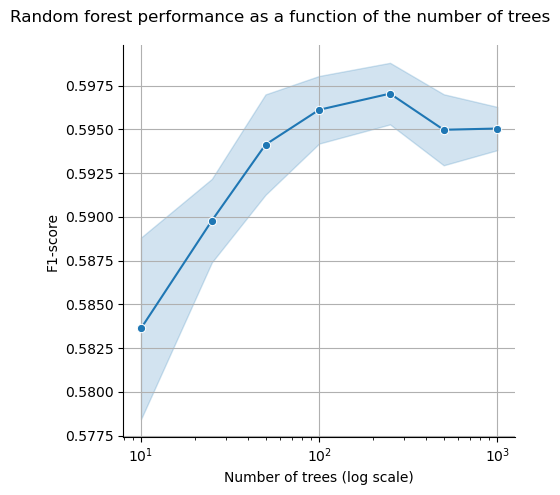

In [135]:
g = sns.relplot(
    data=df_results,
    x="n_trees",
    y="F1",
    kind="line",
    estimator="mean",   # average F1  n_trees
    errorbar="se",      # standard error
    marker="o",
)

g.set(xscale="log")
g.set_axis_labels("Number of trees (log scale)", "F1-score")
g.fig.suptitle("Random forest performance as a function of the number of trees")
plt.tight_layout()
plt.grid()
plt.show()

The plot illustrates how the random forest’s mean F1-score evolves as the number of trees increases. Overall, performance remains within a narrow range (around 0.5825–0.5975), suggesting that even large forests offer only moderate predictive power for this churn dataset.

For very small forests (10–50 trees), the model performs slightly worse and shows much higher variability, as reflected in the wider confidence band. At this stage, predictions are highly sensitive to randomness in the individual trees, leading to unstable performance.

As the number of trees increases into the 50–100 range, the F1-score rises and the uncertainty shrinks substantially. Once the forest reaches roughly 100–250 trees, performance stabilizes: the F1-score reaches its peak values, and the error band becomes narrower.

Beyond approximately 250–500 trees, the curve flattens. While adding more trees reduces variability slightly, the mean F1-score shows virtually no improvement. This indicates that the model has already captured most of the predictive structure present in the data, and additional trees mainly lower variance rather than improve accuracy.

\vspace{0.3 cm}

It is important to note that multiple performance metrics (accuracy, precision, recall, and F1-score) are used to evaluate the classification models, rather than relying on accuracy alone.

ccuracy by itself can be misleading when assessing classification performance in contexts where the dataset is imbalanced. In churn prediction, the number of customers who leave the company is typically smaller than the number who remain. Under these conditions, a model may achieve a high accuracy simply by predicting the majority class (non-churn) most of the time, while still failing to correctly identify a large share of actual churners.

For this reason, additional performance metrics are required to properly assess how well the model handles the minority class. Precision measures the proportion of customers predicted to churn who actually do churn; a low precision implies a high number of false alarms. Recall measures the proportion of true churners that are successfully identified by the model, capturing its ability to detect at-risk customers. The F1-score combines precision and recall into a single metric and is particularly informative when class distributions are uneven or when the costs of false positives and false negatives differ.

By considering accuracy together with precision, recall, and F1-score, we obtain a far more complete and meaningful assessment of the model’s performance.

\vspace{0.5 cm}

# Customer Segmentation (Clustering)

\Large\textbf{Clustering algorithms to identify different customer segments}\normalsize

\vspace{0.3 cm}

## Identification of customer segments using k-means clustering

In [136]:
# X was standardised previously
X_6 = X[["tenure","monthly_charges","total_charges"]]

To identify distinct customer segments based on behavioural and economic characteristics, a k-means clustering analysis was performed using the standardised numerical variables tenure, monthly charges, and total charges.

The algorithm was evaluated for a range of cluster numbers (k = 2 to 10). Two complementary criteria were used to assess clustering quality:

- Inertia (within-cluster sum of squares), to evaluate compactness (elbow method)
- Silhouette score, to assess cluster cohesion and separation

In [137]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   

In [138]:
inertia = []
silhouette = []     

for i in range(2, 11): 
    model = KMeans(
        n_clusters = i,   # number of clusters
        n_init = 10,      # Number of random initialisations 
        random_state = 42 # Seed for reproducibility 
    )
    model.fit(X_6)                     # Train the model
    preds = model.predict(X_6)         # Predict cluster labels
     
    inertia.append(model.inertia_)                   # Store inertia
    silhouette.append(silhouette_score(X_6, preds))  # Store silhouette score
  

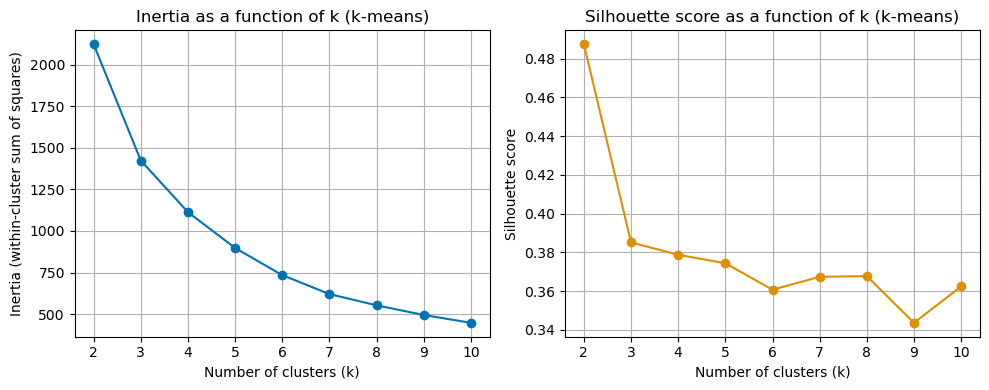

In [139]:
colours = sns.color_palette("colorblind", 2)  # Palette color-blind friendly

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Plot inertia (elbow method)
axes[0].plot(range(2, 11), inertia, marker="o", color=colours[0])
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Inertia as a function of k (k-means)")
axes[0].grid(True)

# Plot silhouette score
axes[1].plot(range(2, 11), silhouette, marker="o", color=colours[1])
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score as a function of k (k-means)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The inertia plot shows a very sharp decrease from $k=2$ to $k=3$, followed by a further substantial drop from $k=3$ to $k=4$. For $k>4$, the curve flattens noticeably, and additional clusters produce only small reductions in the within-cluster sum of squares. The elbow therefore appears around $k=3$ or $k=4$, suggesting that a reasonable choice using this criterion would be either $k=3$ or $k=4$, since beyond this point the improvement in fit becomes marginal.

In contrast, the silhouette score is maximised at $k=2$ (approximately $0.48$) and decreases for larger values of $k$. For $k$ between $3$ and $10$, the silhouette scores are lower and relatively similar, so the clear peak occurs at $k=2$. 

Taken together, the elbow method points towards $k = 3$ or $k = 4$ clusters, whereas the silhouette criterion strongly favours $k = 2$. Since the silhouette score directly measures cluster cohesion and separation, reaching its clear maximum at $k = 2$, and the improvement in inertia beyond $k = 2$ is relatively modest, the most defensible choice is to select $k = 2$ as the optimal number of clusters.

**NOTE**: The option of using 3 clusters was also tested, obtaining the following results: tenure and total charges were still clearly divided into two groups, while monthly charges were split into three clusters (low, medium, and high charges). Because this three-way division affects only one of the variables and the two-cluster structure provides a more coherent segmentation for our data, we ultimately chose $k = 2$ as the most appropriate configuration, even though $k = 3$ remains a valid alternative according to the elbow method.


\vspace{0.3 cm}


## Cluster characterisation and discriminatory variables

Using the selected two-cluster solution, customers were assigned to their nearest cluster centroid and cluster characteristics were analysed using both summary statistics and box plots.

In [140]:
kmeans_2 = KMeans(
    n_clusters = 2,   # number of clusters
    n_init = 10,      # Number of random initialisations 
    random_state = 42 # Seed for reproducibility 
)
kmeans_2.fit(X_6)                      # Train the model
preds_kmeans_2 = kmeans_2.predict(X_6) # Predict cluster labels

pd.Series(preds_kmeans_2).value_counts() # Number of observations in each cluster
X_6_clusters = X_6.copy()
X_6_clusters["cluster"] = preds_kmeans_2 # Cluster label (0, 1, 2)

# Calculate the mean for each variable by cluster
cluster_means = X_6_clusters.groupby("cluster")[["tenure",
                                                 "monthly_charges",
                                                 "total_charges"]].mean() 
cluster_means

,tenure,monthly_charges,total_charges
cluster,,,
0,-0.511010,-0.111291,-0.512539
1,1.412145,0.307547,1.416372


These results reveal a clear two-group structure in the data. Cluster 1 is composed of customers with substantially higher tenure and far higher total charges, indicating a group of long-standing, high-value clients who have accumulated significant spending over time. Monthly charges are also moderately above average in this cluster.

Cluster 0, in contrast, contains customers with lower tenure and lower total charges, consistent with newer customers who have generated much less revenue. Monthly charges in this group lie closer to the overall mean and do not show a strong separation between customers.

Taken together, these differences show that tenure and total charges are the variables that most strongly drive the two-cluster solution.

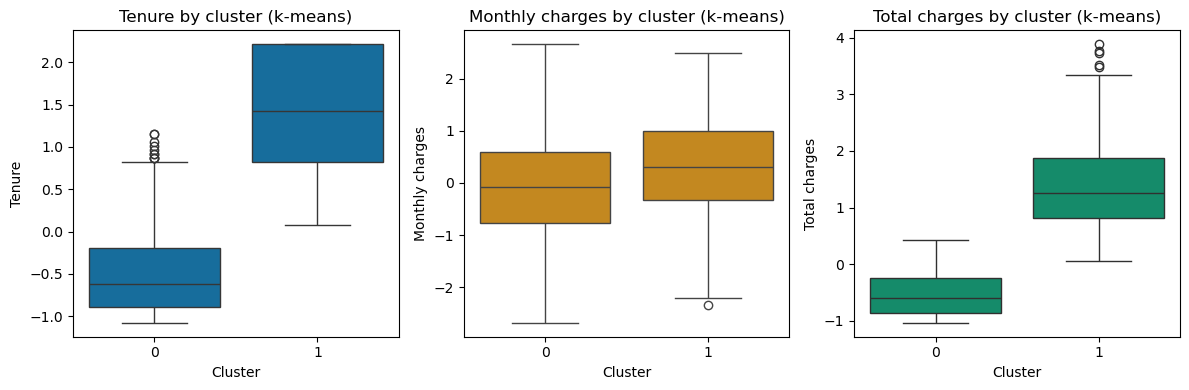

In [141]:
colours = sns.color_palette("colorblind", 3) # Palette color-blind friendly

fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

# Tenure by cluster
sns.boxplot(data=X_6_clusters, x="cluster", y="tenure", 
            ax=axes[0], color=colours[0])
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Tenure")
axes[0].set_title("Tenure by cluster (k-means)")

# Monthly charges by cluster
sns.boxplot(data=X_6_clusters, x="cluster", y="monthly_charges", 
            ax=axes[1],  color=colours[1])
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Monthly charges")
axes[1].set_title("Monthly charges by cluster (k-means)")

# Total charges by cluster
sns.boxplot(data=X_6_clusters, x="cluster", y="total_charges", 
            ax=axes[2],  color=colours[2])
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Total charges")
axes[2].set_title("Total charges by cluster (k-means)")



plt.tight_layout()
plt.show()

The boxplots reinforce the patterns already seen in the cluster means.

Tenure shows the clearest separation: cluster 1 contains customers with much higher tenure and a wider spread of values, while cluster 0 is tightly concentrated at low tenure. This confirms that tenure is one of the main factors driving the clustering.

For monthly charges, the two clusters overlap considerably. Cluster 1 tends to pay slightly more on average, but the difference is small. This suggests that monthly charges play a more subtle role in distinguishing the groups.

Finally, total charges again shows a strong divide: cluster 1 has a much higher median and a wider range, including several high outliers, while cluster 0 remains clustered around lower values. This mirrors the tenure pattern and highlights total charges as another key discriminator.

Overall, the boxplots show that the two-cluster solution is mainly shaped by differences in tenure and total charges, with monthly charges offering only a modest additional separation.

\vspace{0.3 cm}

## Relationship between customer segments and churn

To examine how customer segmentation relates to churn behaviour, scatter plots were produced for key variable pairs, colouring observations by cluster membership. Churn status was then overlaid using different markers.

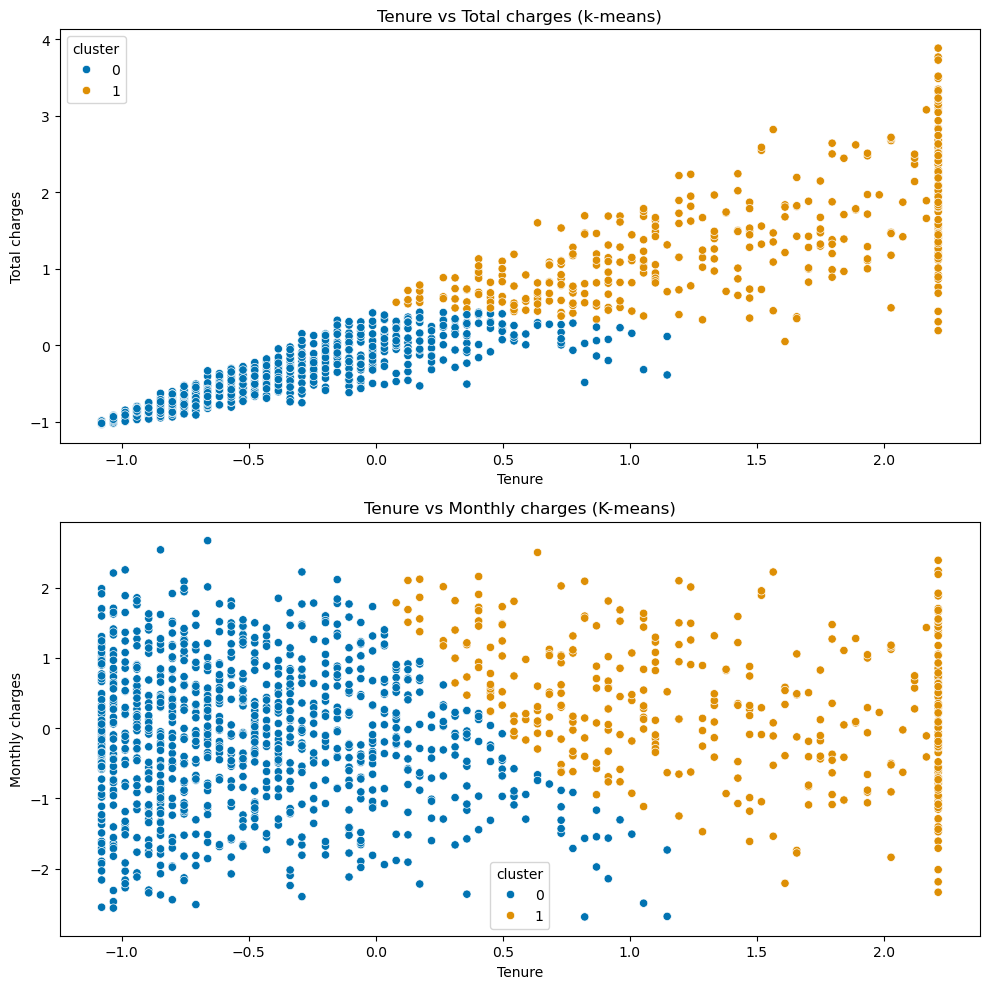

In [142]:
X_6_clusters = X_6.copy()
X_6_clusters["cluster"] = preds_kmeans_2
X_6_clusters["churn"] = telecom_encoded["churn"]

fig, axes = plt.subplots(2 ,1, figsize=(10, 10)) # 2 row, 1 columns

# Flatten the 2×1 array of axes into a simple 1-D list for easier indexing
axes = axes.flatten()
# Tenure vs Total charges 
sns.scatterplot(
    data=X_6_clusters,
    x="tenure",
    y="total_charges",
    hue="cluster",
    ax=axes[0],
    palette="colorblind"   # Palette color-blind friendly
)
axes[0].set_title("Tenure vs Total charges (k-means)")
axes[0].set_xlabel("Tenure")
axes[0].set_ylabel("Total charges")

# Tenure vs Monthly charges
sns.scatterplot(
    data=X_6_clusters,
    x="tenure",
    y="monthly_charges",
    hue="cluster",
    ax=axes[1],
    palette="colorblind"  # Palette color-blind friendly
)
axes[1].set_title("Tenure vs Monthly charges (K-means)")
axes[1].set_xlabel("Tenure")
axes[1].set_ylabel("Monthly charges")

plt.tight_layout()
plt.show()

The tenure vs total charges plot shows a very clear separation between the two clusters. Cluster 1 forms a distinct group with both higher tenure and much higher total charges, while Cluster 0 occupies the region characterised by low tenure and low total charges. The points follow an almost linear pattern, which reflects the natural relationship between tenure and accumulated spending, consistent with the strong correlation observed earlier in Question 3(c).

In contrast, the separation is less pronounced in the tenure vs monthly charges plot. Cluster 0 (short-tenure customers) spreads across the full range of monthly charges, while Cluster 1 (long-tenure customers) tends to show slightly higher monthly charges but still overlaps considerably with Cluster 1. This confirms that monthly charges contribute to the clustering but are not as decisive as tenure or total charges.

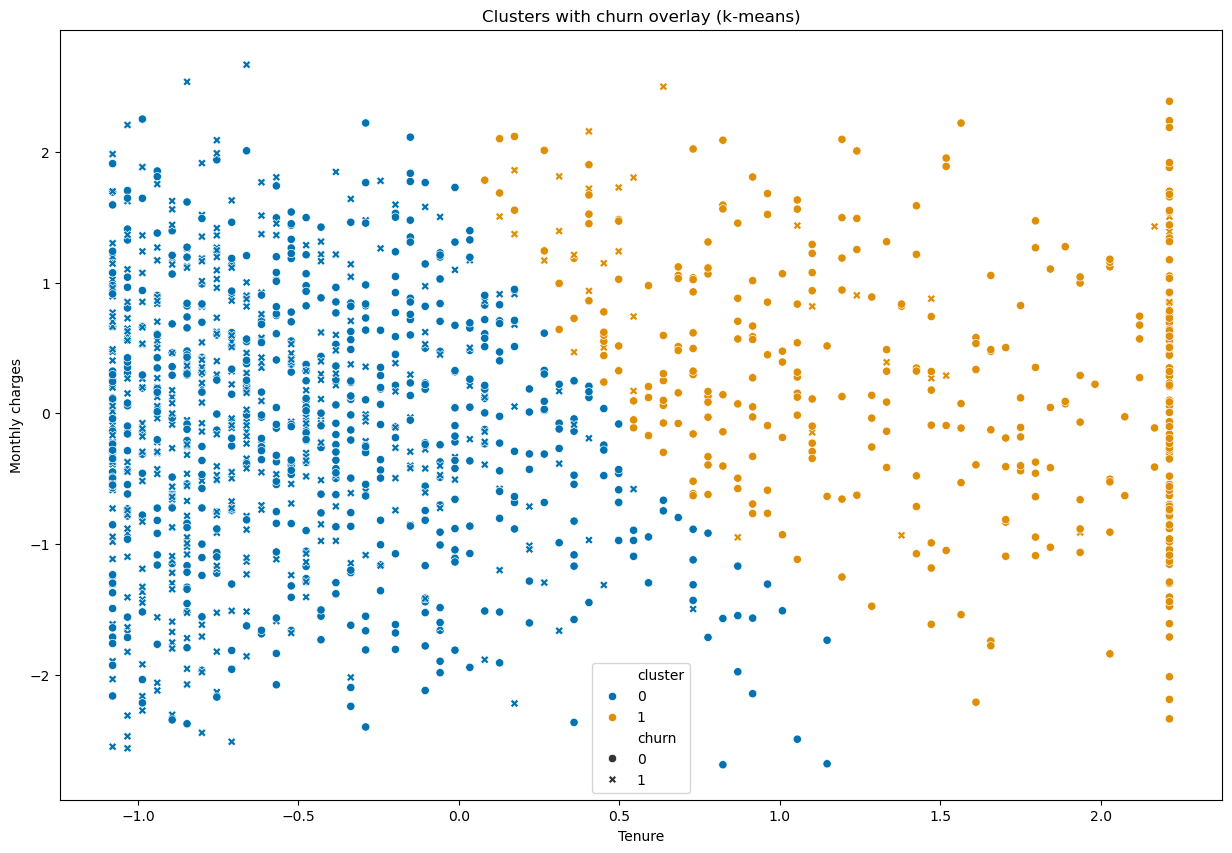

In [143]:
# Tenure vs Monthly charges, churn shown with markers
plt.figure(figsize=(15,10))
ax = sns.scatterplot(
    data=X_6_clusters,
    x="tenure",
    y="monthly_charges",
    hue="cluster",
    style="churn",   # Different marker for churn status
    palette="colorblind" # Palette colour-blind friendly
)
ax.set_title("Clusters with churn overlay (k-means)")
ax.set_xlabel("Tenure")
ax.set_ylabel("Monthly charges")
plt.show()

When  churn  status is added using different markers, the pattern becomes even clearer. Churners (indicated with “×”) concentrate overwhelmingly in Cluster 0 (the group of low-tenure), low-total-charge customers. On the other hand, non-churners (shown as dots) dominate Cluster 1, the high-tenure cluster.

Overall, these plots highlight that  churn  is strongly tied to tenure, regardless of differences in monthly charges. The cluster structure closely mirrors the probability of churn: customers who have been with the company for only a short time are far more likely to leave, whereas long-standing customers rarely churn.

## Robustness check: Spectral Clustering

According to the [sklearn documentation on clustering](https://scikit-learn.org/stable/modules/clustering.html)
, Spectral Clustering is particularly well-suited to datasets with:

- a medium number of samples, and
- a small number of clusters.

Given that our dataset contains approximately 1,400 observations and we are interested in identifying two segments, these conditions align closely with the recommended use cases. While k-means measures distances between points using Euclidean distance, Spectral Clustering is designed to detect more complex cluster shapes by operating on a similarity graph. Therefore, based on the guidance provided in the scikit-learn documentation, Spectral Clustering is an appropriate alternative algorithm to explore for this dataset.

Spectral Clustering is a graph-based clustering technique that leverages the eigenstructure of a similarity matrix to identify groups of observations. Instead of partitioning the data directly in the input space, the algorithm first constructs a similarity graph in which each vertex represents an observation and edges represent similarity. From this graph, a graph Laplacian is computed and its first $k$ eigenvectors are extracted. These eigenvectors form a lower-dimensional embedding of the data that highlights the underlying structure in the similarity graph. 

Hence, a Spectral Clustering analysis was performed using the same numerical features:  tenure ,  monthly_charges  and  total_charges .

Unlike k-means, Spectral Clustering does not provide an inertia value (within-cluster sum of squares), since it is a graph-based method. However, the quality of the clustering for different numbers of clusters can still be evaluated using the silhouette score.

In [144]:
from sklearn.cluster import SpectralClustering

silhouette = []

for k in range(2, 11):
    model = SpectralClustering(
        n_clusters = k,                 # Number of clusters
        affinity = "nearest_neighbors", # Build a similarity graph
        assign_labels = "kmeans",       # Clustering in the embedded space
        n_neighbors = 10,               # Neighbours for the graph
        random_state = 42               # Seed for reproducibility
    )
    
    preds = model.fit_predict(X_6)      # Train and predict cluster labels
    silhouette.append(silhouette_score(X_6, preds))  # Store silhouette score

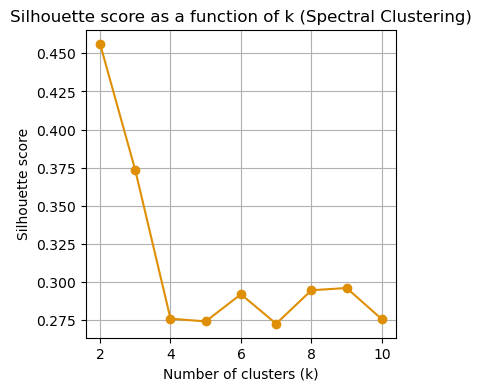

In [145]:
# Plot silhouette score
plt.figure(figsize=(4, 4))
plt.plot(range(2, 11), silhouette, marker="o", color=colours[1])
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score as a function of k (Spectral Clustering)")
plt.grid(True)
plt.show()

Cluster quality was evaluated using the silhouette score for different values of k. As with k-means, the silhouette score reaches a clear maximum at k = 2, indicating that the data naturally forms two well-separated groups.

Since the silhouette analysis identified $k=2$ as the optimal number of clusters for Spectral Clustering, the model was fitted using this value and analyse the resulting groups.

In [146]:
spectral_2 = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42
)

preds_spectral_2 = spectral_2.fit_predict(X_6)   # Fit model and obtain labels

# Number of observations in each cluster
pd.Series(preds_spectral_2).value_counts() 

# Add cluster labels to the dataset
X_6_clusters_s = X_6.copy()
X_6_clusters_s["cluster"] = preds_spectral_2

# Calculate the mean for each variable by cluster
cluster_means_s = X_6_clusters_s.groupby("cluster")[["tenure",
                                                 "monthly_charges",
                                                 "total_charges"]].mean()
cluster_means_s

,tenure,monthly_charges,total_charges
cluster,,,
0,-0.596541,-0.103426,-0.581462
1,1.222974,0.212035,1.192060


The two-cluster Spectral Clustering solution yields results that closely mirror those obtained with k-means:

- One cluster is characterised by high tenure and high total charges, representing stable, high-value customers.

- The other cluster consists of short-tenure, low-value customers, with substantially higher churn incidence.

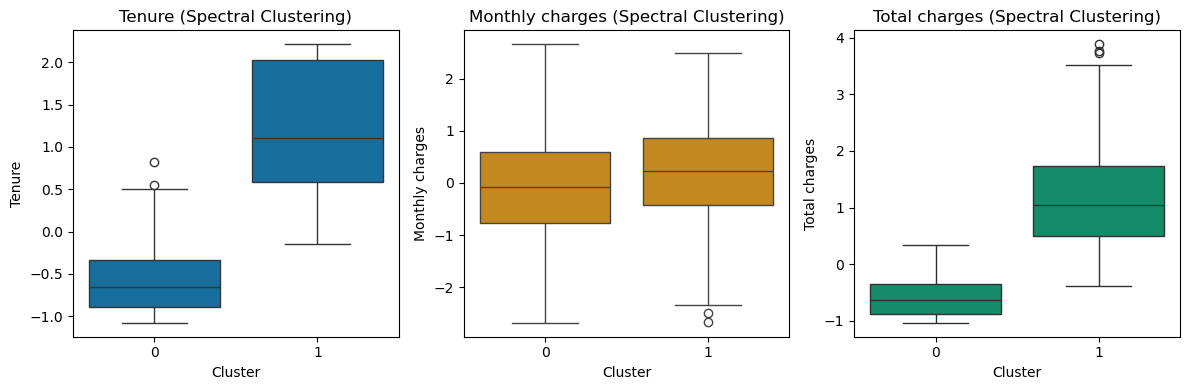

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Palette colour-blind friendly
colours = sns.color_palette("colorblind", 3)

# Tenure by cluster
sns.boxplot(data=X_6_clusters_s, x="cluster", y="tenure", 
            ax=axes[0], color=colours[0])
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Tenure")
axes[0].set_title("Tenure (Spectral Clustering)")

# Monthly charges by cluster
sns.boxplot(data=X_6_clusters_s, x="cluster", y="monthly_charges", 
            ax=axes[1], color=colours[1])
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Monthly charges")
axes[1].set_title("Monthly charges (Spectral Clustering)")

# Total charges by cluster
sns.boxplot(data=X_6_clusters_s, x="cluster", y="total_charges", 
            ax=axes[2], color=colours[2])
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Total charges")
axes[2].set_title("Total charges (Spectral Clustering)")

plt.tight_layout()
plt.show()

The Spectral Clustering boxplots display the same patterns observed in the mean comparison and closely mirror the results obtained with k-means. Once again, the two-cluster structure is primarily driven by clear differences in tenure and total charges, while monthly charges contribute only a modest degree of additional separation.

As before, we also examined the relationship between  tenure ,  monthly_charges , and  churn .

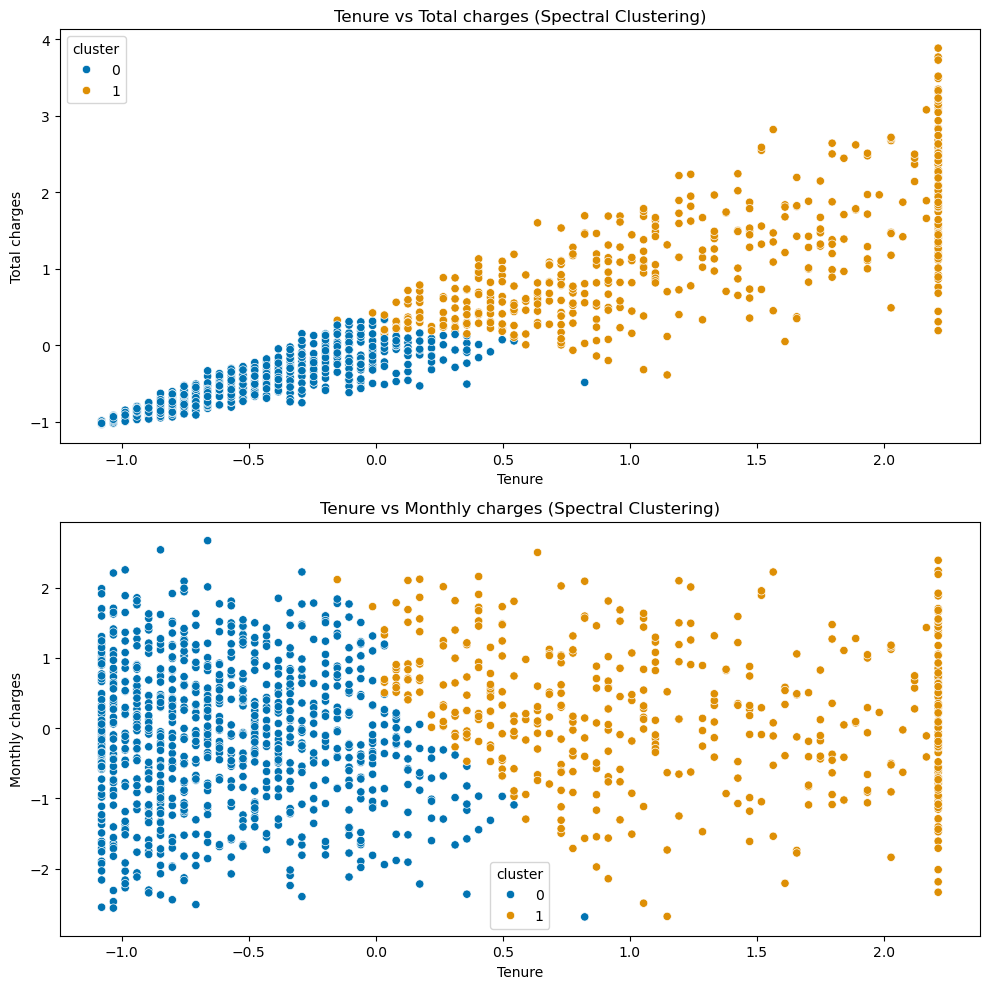

In [148]:
# Add churn to the dataset
X_6_clusters_s["churn"] = telecom_std["churn"]

# Create scatterplots for the key variables
fig, axes = plt.subplots(2 ,1, figsize=(10, 10)) # 2 row, 1 columns

# Flatten the 2×1 array of axes into a simple 1-D list for easier indexing
axes = axes.flatten()

# Tenure vs Total charges (coloured by cluster)
sns.scatterplot(
    data=X_6_clusters_s,
    x="tenure",
    y="total_charges",
    hue="cluster",
    ax=axes[0],
    palette="colorblind"
)
axes[0].set_title("Tenure vs Total charges (Spectral Clustering)")
axes[0].set_xlabel("Tenure")
axes[0].set_ylabel("Total charges")

# Tenure vs Monthly charges (coloured by cluster)
sns.scatterplot(
    data=X_6_clusters_s,
    x="tenure",
    y="monthly_charges",
    hue="cluster",
    ax=axes[1],
    palette="colorblind"
)
axes[1].set_title("Tenure vs Monthly charges (Spectral Clustering)")
axes[1].set_xlabel("Tenure")
axes[1].set_ylabel("Monthly charges")

plt.tight_layout()
plt.show()


The tenure vs. total charges scatter plot shows a very clear separation between the two groups identified by Spectral Clustering. In contrast, the separation is less pronounced in the tenure vs. monthly charges plot, where the clusters overlap more noticeably. Importantly, the overall shape and structure of both scatterplots are almost identical to those obtained using k-means.

In [ ]:
plt.figure(figsize=(15,10))
ax = sns.scatterplot(
    data=X_6_clusters_s,
    x="tenure",
    y="monthly_charges",
    hue="cluster",
    style="churn",   # Different marker for churn status
    palette="colorblind" # Palette colour-blind friendly
)
ax.set_title("Clusters with churn overlay (Spectral Clustering)")
ax.set_xlabel("Tenure")
ax.set_ylabel("Monthly charges")
plt.show()

When  churn  status is overlaid on the scatter plots, the relationship between customer behaviour and churn becomes very clear. In the Spectral Clustering solution, churners are concentrated almost entirely within the cluster characterised by low tenure and low total charges, while the high-tenure, high-value cluster consists predominantly of non-churners. This pattern closely mirrors what we observed using k-means.

The overall shape and distribution of the clusters are essentially the same in both algorithms. In each case, customers with short tenure and lower total charges are far more likely to churn, whereas long-tenure, high-value customers rarely do so. Monthly charges show considerable overlap across clusters and therefore contribute relatively little to explaining churn behaviour.

The consistency between the Spectral Clustering and k-means visualisations indicates that the churn signal is highly robust across different clustering approaches. Whether clusters are formed using Euclidean distance (k-means) or a graph-based similarity representation (Spectral Clustering), the same underlying segmentation emerges

# Conclusions & Strategic Implications

This project combines data analysis, statistical testing, predictive modelling, and clustering to explore customer churn in the telecommunications sector. By analysing both monthly and yearly contracts together, it offers a clear and coherent view of the factors that shape customer retention.

Across all methods, one result stands out: tenure is the strongest predictor of churn. Customers are far more likely to leave early in their relationship, while long-standing customers rarely churn. This pattern appears consistently in descriptive analysis, statistical tests, predictive models, and clustering results.

Contract structure also plays a key role. Customers on yearly contracts churn significantly less than those on monthly contracts, even though their monthly charges are similar. This suggests that stability and commitment matter more for retention than pricing alone. Service-related factors reinforce this view: access to technical support is associated with lower churn, while certain payment methods, such as electronic checks, are linked to higher churn risk.

Importantly, once tenure and contract type are taken into account, monthly charges have little independent effect on churn. This challenges simple price-based explanations and highlights the importance of customer engagement over time.

From a strategic perspective, the findings point clearly towards the early customer lifecycle. Improving onboarding, early support, and engagement during the first year is likely to be the most effective way to reduce churn. The strong agreement between statistical and machine learning models adds confidence to these conclusions and supports their use in evidence-based decision-making.

While predictive performance is reasonable, the models still miss a portion of churn events, suggesting scope for improvement through richer behavioural or usage data. Future work could also examine causal effects and regulatory influences on customer switching behaviour.